
# Batched eigensystems of complex Hermitian $3\times 3$ matrices

This notebook compares three ways of computing the **complete eigensystem** (eigenvalues and eigenvectors) of a batch of complex Hermitian $3\times 3$ matrices:

1. **NumPy/LAPACK on CPU** via `numpy.linalg.eigh`;
2. **Analytical Cardano-like method on CPU**, JIT-compiled with Numba and parallelized across the batch;
3. **Analytical Cardano-like method on GPU**, implemented as a CUDA kernel compiled through PyCUDA, with one CUDA thread per matrix.

The analytical method follows the strategy described by J. Kopp, *Efficient numerical diagonalization of hermitian 3 x 3 matrices* (2008): Cardano's formula for the eigenvalues and vector cross products for the eigenvectors. The implementation below adds safeguards for nearly degenerate cases and always returns an orthonormal eigenvector matrix.

All benchmark matrices use `complex64` / `float32` so that CPU and GPU arithmetic use the same nominal precision. NumPy/LAPACK is used as the numerical reference. Matrix generation and host-side packing are excluded from solver timings.


In [1]:

# Run this cell in a CUDA-enabled environment (for example, a GPU Colab runtime).
%pip -q install pycuda numba pandas matplotlib threadpoolctl


In [2]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from numba import njit, prange, get_num_threads
from threadpoolctl import threadpool_info

try:
    import pycuda.autoinit
    import pycuda.driver as cuda
    from pycuda.compiler import SourceModule
    GPU_AVAILABLE = True
    GPU_NAME = cuda.Device(0).name()
except Exception as exc:
    GPU_AVAILABLE = False
    GPU_NAME = None
    GPU_IMPORT_ERROR = exc

print(f"Numba CPU threads: {get_num_threads()}")
print("CPU math libraries:")
for item in threadpool_info():
    print(f"  {item.get('internal_api', '?')}: {item.get('num_threads', '?')} threads, {item.get('filepath', '')}")

if GPU_AVAILABLE:
    print(f"CUDA device: {GPU_NAME}")
else:
    print(f"CUDA unavailable: {GPU_IMPORT_ERROR}")


Numba CPU threads: 2
CPU math libraries:
  openblas: 2 threads, /usr/local/lib/python3.13/dist-packages/numpy.libs/libscipy_openblas64_-ff651d7f.so
CUDA device: Tesla T4



## Random Hermitian batches

The diagonal is real and the upper-triangular entries are complex Gaussian random variables. The lower triangle is filled by Hermitian conjugation. The resulting matrices are generic Hermitian matrices; they are not forced to be positive definite.


In [3]:

def make_hermitian_batch(n, seed=0):
    rng = np.random.default_rng(seed)

    diag = rng.standard_normal((n, 3)).astype(np.float32)
    upper = (
        rng.standard_normal((n, 3))
        + 1j * rng.standard_normal((n, 3))
    ).astype(np.complex64)

    A = np.empty((n, 3, 3), dtype=np.complex64)
    A[:, 0, 0] = diag[:, 0]
    A[:, 1, 1] = diag[:, 1]
    A[:, 2, 2] = diag[:, 2]

    A[:, 0, 1] = upper[:, 0]
    A[:, 1, 0] = np.conj(upper[:, 0])
    A[:, 0, 2] = upper[:, 1]
    A[:, 2, 0] = np.conj(upper[:, 1])
    A[:, 1, 2] = upper[:, 2]
    A[:, 2, 1] = np.conj(upper[:, 2])
    return A


def pack_upper_triangle(A):
    """Return contiguous arrays used by the CUDA kernel."""
    return (
        np.ascontiguousarray(A[:, 0, 0].real, dtype=np.float32),
        np.ascontiguousarray(A[:, 1, 1].real, dtype=np.float32),
        np.ascontiguousarray(A[:, 2, 2].real, dtype=np.float32),
        np.ascontiguousarray(A[:, 0, 1], dtype=np.complex64),
        np.ascontiguousarray(A[:, 0, 2], dtype=np.complex64),
        np.ascontiguousarray(A[:, 1, 2], dtype=np.complex64),
    )



## CPU reference: NumPy/LAPACK

`numpy.linalg.eigh` is specialized for Hermitian matrices and returns eigenvalues in ascending order and normalized eigenvectors in the columns of the returned matrix.


In [4]:

def cpu_library_eigh(A):
    return np.linalg.eigh(A)



## CPU analytical method

For

$$
A=\begin{bmatrix}
a_{11}&a_{12}&a_{13}\\
a_{12}^*&a_{22}&a_{23}\\
a_{13}^*&a_{23}^*&a_{33}
\end{bmatrix},
$$

the characteristic polynomial is written as

$$
\lambda^3+c_2\lambda^2+c_1\lambda+c_0=0.
$$

The coefficients are evaluated directly from the six independent matrix entries. Cardano's trigonometric form is then used for the three real eigenvalues. The radicand used to compute the angle is the cancellation-resistant expression given by Kopp rather than a direct evaluation of $p^3-q^2$.

For eigenvectors, cross products of rows of $A-\lambda I$ are used. Instead of always using the same pair, the implementation selects the row pair whose cross product has the largest norm. Near degeneracy, it switches to a small null-space fallback and explicitly orthogonalizes the second vector. The third vector is obtained from the first two, which guarantees an orthonormal basis up to roundoff.


In [5]:

SQRT3_F = np.float32(1.7320508075688772)
EPS32 = np.float32(np.finfo(np.float32).eps)


@njit(inline='always')
def _abs2(z):
    return z.real * z.real + z.imag * z.imag


@njit(inline='always')
def _cross3(a, b):
    c = np.empty(3, dtype=np.complex64)
    c[0] = a[1] * b[2] - a[2] * b[1]
    c[1] = a[2] * b[0] - a[0] * b[2]
    c[2] = a[0] * b[1] - a[1] * b[0]
    return c


@njit(inline='always')
def _vec_norm2(v):
    return _abs2(v[0]) + _abs2(v[1]) + _abs2(v[2])


@njit(inline='always')
def _normalize(v):
    n2 = _vec_norm2(v)
    if n2 > 0.0:
        inv = np.float32(1.0) / np.sqrt(n2)
        v[0] *= inv
        v[1] *= inv
        v[2] *= inv
    return n2


@njit(inline='always')
def _cardano_eigenvalues(a11, a22, a33, a12, a13, a23):
    aa12 = _abs2(a12)
    aa13 = _abs2(a13)
    aa23 = _abs2(a23)

    c2 = -(a11 + a22 + a33)
    c1 = a11 * a22 + a11 * a33 + a22 * a33 - (aa12 + aa13 + aa23)
    triple_product = np.conj(a13) * a12 * a23
    c0 = (
        a11 * aa23 + a22 * aa13 + a33 * aa12
        - a11 * a22 * a33
        - np.float32(2.0) * triple_product.real
    )

    p = c2 * c2 - np.float32(3.0) * c1
    q = (
        -np.float32(13.5) * c0
        - c2 * c2 * c2
        + np.float32(4.5) * c2 * c1
    )

    p_tol = np.float32(64.0) * EPS32 * (
        abs(c2 * c2) + abs(c1) + np.float32(1.0)
    )

    if p <= p_tol:
        l0 = l1 = l2 = -c2 / np.float32(3.0)
    else:
        # Stable form of p^3 - q^2 from Kopp's Eq. (32).
        rad = np.float32(27.0) * (
            np.float32(0.25) * c1 * c1 * (p - c1)
            + c0 * (q + np.float32(6.75) * c0)
        )
        if rad < 0.0:
            rad = np.float32(0.0)

        phi = np.arctan2(np.sqrt(rad), q) / np.float32(3.0)
        sqrt_p = np.sqrt(max(p, np.float32(0.0)))
        cp = sqrt_p * np.cos(phi)
        sp = sqrt_p * np.sin(phi)

        l0 = (np.float32(2.0) * cp - c2) / np.float32(3.0)
        l1 = (-cp - SQRT3_F * sp - c2) / np.float32(3.0)
        l2 = (-cp + SQRT3_F * sp - c2) / np.float32(3.0)

    # Sorting network: ascending order, matching numpy.linalg.eigh.
    if l0 > l1:
        l0, l1 = l1, l0
    if l1 > l2:
        l1, l2 = l2, l1
    if l0 > l1:
        l0, l1 = l1, l0
    return l0, l1, l2


@njit(inline='always')
def _orthogonalize_against(v, q):
    dot = np.conj(q[0]) * v[0] + np.conj(q[1]) * v[1] + np.conj(q[2]) * v[2]
    v[0] -= dot * q[0]
    v[1] -= dot * q[1]
    v[2] -= dot * q[2]


@njit(inline='always')
def _eigenvector_from_lambda(A, lam, previous, use_previous, cross_threshold):
    M = A.copy()
    M[0, 0] -= lam
    M[1, 1] -= lam
    M[2, 2] -= lam

    c01 = _cross3(M[0], M[1])
    c02 = _cross3(M[0], M[2])
    c12 = _cross3(M[1], M[2])

    n01 = _vec_norm2(c01)
    n02 = _vec_norm2(c02)
    n12 = _vec_norm2(c12)

    if n02 > n01 and n02 >= n12:
        v = c02
        best = n02
    elif n12 > n01 and n12 > n02:
        v = c12
        best = n12
    else:
        v = c01
        best = n01

    if best <= cross_threshold:
        # Near a repeated eigenvalue the matrix can have rank one.
        # Use the strongest row to construct several null-space candidates.
        rn0 = _vec_norm2(M[0])
        rn1 = _vec_norm2(M[1])
        rn2 = _vec_norm2(M[2])
        if rn1 > rn0 and rn1 >= rn2:
            r = M[1]
        elif rn2 > rn0 and rn2 > rn1:
            r = M[2]
        else:
            r = M[0]

        candidates = np.zeros((6, 3), dtype=np.complex64)
        candidates[0, 0] = -r[1]; candidates[0, 1] = r[0]
        candidates[1, 0] = -r[2]; candidates[1, 2] = r[0]
        candidates[2, 1] = -r[2]; candidates[2, 2] = r[1]
        candidates[3, 0] = 1.0 + 0.0j
        candidates[4, 1] = 1.0 + 0.0j
        candidates[5, 2] = 1.0 + 0.0j

        best_norm = np.float32(-1.0)
        best_idx = 0
        for k in range(6):
            vv = candidates[k].copy()
            if use_previous:
                _orthogonalize_against(vv, previous)
            nn = _vec_norm2(vv)
            if nn > best_norm:
                best_norm = nn
                best_idx = k
        v = candidates[best_idx].copy()

    if use_previous:
        _orthogonalize_against(v, previous)

    if _vec_norm2(v) <= np.float32(1e-30):
        # Final basis-vector fallback, used only for highly degenerate cases.
        best_norm = np.float32(-1.0)
        best_idx = 0
        for k in range(3):
            vv = np.zeros(3, dtype=np.complex64)
            vv[k] = 1.0 + 0.0j
            if use_previous:
                _orthogonalize_against(vv, previous)
            nn = _vec_norm2(vv)
            if nn > best_norm:
                best_norm = nn
                best_idx = k
        v = np.zeros(3, dtype=np.complex64)
        v[best_idx] = 1.0 + 0.0j
        if use_previous:
            _orthogonalize_against(v, previous)

    _normalize(v)
    return v


@njit(parallel=True)
def cpu_cardano_eigh(A):
    n = A.shape[0]
    w = np.empty((n, 3), dtype=np.float32)
    V = np.empty((n, 3, 3), dtype=np.complex64)
    no_previous = np.zeros(3, dtype=np.complex64)

    for k in prange(n):
        a11 = np.float32(A[k, 0, 0].real)
        a22 = np.float32(A[k, 1, 1].real)
        a33 = np.float32(A[k, 2, 2].real)
        a12 = np.complex64(A[k, 0, 1])
        a13 = np.complex64(A[k, 0, 2])
        a23 = np.complex64(A[k, 1, 2])

        l0, l1, l2 = _cardano_eigenvalues(a11, a22, a33, a12, a13, a23)
        w[k, 0] = l0
        w[k, 1] = l1
        w[k, 2] = l2

        M = np.empty((3, 3), dtype=np.complex64)
        M[0, 0] = a11;          M[0, 1] = a12;          M[0, 2] = a13
        M[1, 0] = np.conj(a12); M[1, 1] = a22;          M[1, 2] = a23
        M[2, 0] = np.conj(a13); M[2, 1] = np.conj(a23); M[2, 2] = a33

        wmax = max(abs(l0), max(abs(l1), abs(l2)))
        Lambda = max(wmax * wmax, wmax)
        cross_threshold = np.float32(256.0) * EPS32 * Lambda * Lambda

        v0 = _eigenvector_from_lambda(M, l0, no_previous, False, cross_threshold)
        v1 = _eigenvector_from_lambda(M, l1, v0, True, cross_threshold)

        v2 = np.conj(_cross3(v0, v1))
        if _normalize(v2) <= np.float32(1e-30):
            v2 = _eigenvector_from_lambda(M, l2, v0, True, cross_threshold)
            _orthogonalize_against(v2, v1)
            _normalize(v2)

        for row in range(3):
            V[k, row, 0] = v0[row]
            V[k, row, 1] = v1[row]
            V[k, row, 2] = v2[row]

    return w, V



## CUDA analytical method

The CUDA implementation mirrors the CPU analytical method. Each thread reads one packed Hermitian matrix, computes its three eigenvalues and three eigenvectors, and writes one complete eigensystem. There is no communication between threads and no shared-memory synchronization.

The kernel intentionally does **not** perturb the diagonal entries. It reconstructs the full Hermitian matrix before computing eigenvectors, and it uses the same degeneracy safeguards as the CPU analytical implementation.


In [6]:

gpu_source = r"""
#include <pycuda-complex.hpp>
#include <math.h>

typedef pycuda::complex<float> cmplx;

#define EPS32 1.1920928955078125e-7f
#define SQRT3F 1.7320508075688772935f

__device__ __forceinline__ float abs2c(cmplx z) {
    return z.real()*z.real() + z.imag()*z.imag();
}

__device__ __forceinline__ float vnorm2(const cmplx *v) {
    return abs2c(v[0]) + abs2c(v[1]) + abs2c(v[2]);
}

__device__ __forceinline__ void cross3(const cmplx *a, const cmplx *b, cmplx *c) {
    c[0] = a[1]*b[2] - a[2]*b[1];
    c[1] = a[2]*b[0] - a[0]*b[2];
    c[2] = a[0]*b[1] - a[1]*b[0];
}

__device__ __forceinline__ void normalize3(cmplx *v) {
    float n2 = vnorm2(v);
    if (n2 > 0.0f) {
        float inv = rsqrtf(n2);
        v[0] *= inv; v[1] *= inv; v[2] *= inv;
    }
}

__device__ __forceinline__ void orthogonalize(cmplx *v, const cmplx *q) {
    cmplx dot = conj(q[0])*v[0] + conj(q[1])*v[1] + conj(q[2])*v[2];
    v[0] -= dot*q[0];
    v[1] -= dot*q[1];
    v[2] -= dot*q[2];
}

__device__ __forceinline__ void sort3(float &a, float &b, float &c) {
    float t;
    if (a > b) { t=a; a=b; b=t; }
    if (b > c) { t=b; b=c; c=t; }
    if (a > b) { t=a; a=b; b=t; }
}

__device__ __forceinline__ void cardano_values(
    float a11, float a22, float a33,
    cmplx a12, cmplx a13, cmplx a23,
    float *w)
{
    float aa12 = abs2c(a12);
    float aa13 = abs2c(a13);
    float aa23 = abs2c(a23);

    float c2 = -(a11 + a22 + a33);
    float c1 = a11*a22 + a11*a33 + a22*a33 - (aa12 + aa13 + aa23);
    cmplx triple_product = conj(a13) * a12 * a23;
    float c0 = a11*aa23 + a22*aa13 + a33*aa12
             - a11*a22*a33 - 2.0f*triple_product.real();

    float p = c2*c2 - 3.0f*c1;
    float q = -13.5f*c0 - c2*c2*c2 + 4.5f*c2*c1;
    float p_tol = 64.0f*EPS32*(fabsf(c2*c2) + fabsf(c1) + 1.0f);

    float l0, l1, l2;
    if (p <= p_tol) {
        l0 = l1 = l2 = -c2/3.0f;
    } else {
        float rad = 27.0f*(0.25f*c1*c1*(p-c1) + c0*(q + 6.75f*c0));
        rad = fmaxf(rad, 0.0f);
        float phi = atan2f(sqrtf(rad), q)/3.0f;
        float sqrt_p = sqrtf(fmaxf(p, 0.0f));
        float cp = sqrt_p*cosf(phi);
        float sp = sqrt_p*sinf(phi);

        l0 = (2.0f*cp - c2)/3.0f;
        l1 = (-cp - SQRT3F*sp - c2)/3.0f;
        l2 = (-cp + SQRT3F*sp - c2)/3.0f;
    }

    sort3(l0, l1, l2);
    w[0] = l0; w[1] = l1; w[2] = l2;
}

__device__ void fallback_vector(
    cmplx M[3][3], const cmplx *previous, bool use_previous, cmplx *out)
{
    float rn0 = abs2c(M[0][0]) + abs2c(M[0][1]) + abs2c(M[0][2]);
    float rn1 = abs2c(M[1][0]) + abs2c(M[1][1]) + abs2c(M[1][2]);
    float rn2 = abs2c(M[2][0]) + abs2c(M[2][1]) + abs2c(M[2][2]);
    int ridx = 0;
    if (rn1 > rn0 && rn1 >= rn2) ridx = 1;
    else if (rn2 > rn0 && rn2 > rn1) ridx = 2;

    cmplx r0 = M[ridx][0];
    cmplx r1 = M[ridx][1];
    cmplx r2 = M[ridx][2];

    float best = -1.0f;
    cmplx bestv[3] = {cmplx(1.0f,0.0f), cmplx(0.0f,0.0f), cmplx(0.0f,0.0f)};
    cmplx cand[3];

    for (int k=0; k<6; ++k) {
        cand[0] = cmplx(0.0f,0.0f);
        cand[1] = cmplx(0.0f,0.0f);
        cand[2] = cmplx(0.0f,0.0f);

        if (k == 0) { cand[0] = -r1; cand[1] = r0; }
        if (k == 1) { cand[0] = -r2; cand[2] = r0; }
        if (k == 2) { cand[1] = -r2; cand[2] = r1; }
        if (k == 3) cand[0] = cmplx(1.0f,0.0f);
        if (k == 4) cand[1] = cmplx(1.0f,0.0f);
        if (k == 5) cand[2] = cmplx(1.0f,0.0f);

        if (use_previous) orthogonalize(cand, previous);
        float nn = vnorm2(cand);
        if (nn > best) {
            best = nn;
            bestv[0] = cand[0]; bestv[1] = cand[1]; bestv[2] = cand[2];
        }
    }

    out[0] = bestv[0]; out[1] = bestv[1]; out[2] = bestv[2];
    normalize3(out);
}

__device__ __forceinline__ void eigenvector_from_lambda(
    cmplx A[3][3], float lam, const cmplx *previous, bool use_previous,
    float cross_threshold, cmplx *out)
{
    cmplx M[3][3];
    #pragma unroll
    for (int i=0; i<3; ++i) {
        #pragma unroll
        for (int j=0; j<3; ++j) M[i][j] = A[i][j];
        M[i][i] -= cmplx(lam, 0.0f);
    }

    cmplx c01[3], c02[3], c12[3];
    cross3(M[0], M[1], c01);
    cross3(M[0], M[2], c02);
    cross3(M[1], M[2], c12);
    float n01 = vnorm2(c01);
    float n02 = vnorm2(c02);
    float n12 = vnorm2(c12);

    float best;
    if (n02 > n01 && n02 >= n12) {
        out[0]=c02[0]; out[1]=c02[1]; out[2]=c02[2]; best=n02;
    } else if (n12 > n01 && n12 > n02) {
        out[0]=c12[0]; out[1]=c12[1]; out[2]=c12[2]; best=n12;
    } else {
        out[0]=c01[0]; out[1]=c01[1]; out[2]=c01[2]; best=n01;
    }

    if (best <= cross_threshold) {
        fallback_vector(M, previous, use_previous, out);
        return;
    }

    if (use_previous) orthogonalize(out, previous);
    if (vnorm2(out) <= 1.0e-30f) {
        fallback_vector(M, previous, use_previous, out);
        return;
    }
    normalize3(out);
}

extern "C" __global__ void hermitian_eigh3_batch(
    const float *a11, const float *a22, const float *a33,
    const cmplx *a12, const cmplx *a13, const cmplx *a23,
    int n, float *eigvals, cmplx *eigvecs)
{
    int idx = blockIdx.x*blockDim.x + threadIdx.x;
    if (idx >= n) return;

    float d11 = a11[idx];
    float d22 = a22[idx];
    float d33 = a33[idx];
    cmplx z12 = a12[idx];
    cmplx z13 = a13[idx];
    cmplx z23 = a23[idx];

    float w[3];
    cardano_values(d11, d22, d33, z12, z13, z23, w);

    cmplx A[3][3];
    A[0][0] = cmplx(d11,0.0f); A[0][1] = z12;             A[0][2] = z13;
    A[1][0] = conj(z12);         A[1][1] = cmplx(d22,0.0f); A[1][2] = z23;
    A[2][0] = conj(z13);         A[2][1] = conj(z23);       A[2][2] = cmplx(d33,0.0f);

    float wmax = fmaxf(fabsf(w[0]), fmaxf(fabsf(w[1]), fabsf(w[2])));
    float Lambda = fmaxf(wmax*wmax, wmax);
    float cross_threshold = 256.0f*EPS32*Lambda*Lambda;

    cmplx none[3] = {cmplx(0.0f,0.0f), cmplx(0.0f,0.0f), cmplx(0.0f,0.0f)};
    cmplx v0[3], v1[3], v2[3];
    eigenvector_from_lambda(A, w[0], none, false, cross_threshold, v0);
    eigenvector_from_lambda(A, w[1], v0, true, cross_threshold, v1);

    cmplx tmp[3];
    cross3(v0, v1, tmp);
    v2[0] = conj(tmp[0]); v2[1] = conj(tmp[1]); v2[2] = conj(tmp[2]);
    if (vnorm2(v2) <= 1.0e-30f) {
        eigenvector_from_lambda(A, w[2], v0, true, cross_threshold, v2);
        orthogonalize(v2, v1);
    }
    normalize3(v2);

    eigvals[3*idx + 0] = w[0];
    eigvals[3*idx + 1] = w[1];
    eigvals[3*idx + 2] = w[2];

    #pragma unroll
    for (int r=0; r<3; ++r) {
        eigvecs[9*idx + 3*r + 0] = v0[r];
        eigvecs[9*idx + 3*r + 1] = v1[r];
        eigvecs[9*idx + 3*r + 2] = v2[r];
    }
}
"""

if GPU_AVAILABLE:
    cuda_module = SourceModule(gpu_source, no_extern_c=True)
    cuda_eigh3_kernel = cuda_module.get_function("hermitian_eigh3_batch")
    print("CUDA kernel compiled successfully.")
else:
    cuda_eigh3_kernel = None


CUDA kernel compiled successfully.


In [7]:

class GpuEigh3Batch:
    """Reusable device buffers for a fixed batch size."""

    def __init__(self, n, block_size=256):
        if not GPU_AVAILABLE:
            raise RuntimeError("CUDA is not available in this runtime.")
        self.n = int(n)
        self.block = (int(block_size), 1, 1)
        self.grid = ((self.n + block_size - 1)//block_size, 1, 1)

        self.host_w = np.empty((self.n, 3), dtype=np.float32)
        self.host_V = np.empty((self.n, 3, 3), dtype=np.complex64)

        n_real = self.n * np.dtype(np.float32).itemsize
        n_complex = self.n * np.dtype(np.complex64).itemsize
        self.d_a11 = cuda.mem_alloc(n_real)
        self.d_a22 = cuda.mem_alloc(n_real)
        self.d_a33 = cuda.mem_alloc(n_real)
        self.d_a12 = cuda.mem_alloc(n_complex)
        self.d_a13 = cuda.mem_alloc(n_complex)
        self.d_a23 = cuda.mem_alloc(n_complex)
        self.d_w = cuda.mem_alloc(self.host_w.nbytes)
        self.d_V = cuda.mem_alloc(self.host_V.nbytes)

    def upload(self, packed):
        a11, a22, a33, a12, a13, a23 = packed
        cuda.memcpy_htod(self.d_a11, a11)
        cuda.memcpy_htod(self.d_a22, a22)
        cuda.memcpy_htod(self.d_a33, a33)
        cuda.memcpy_htod(self.d_a12, a12)
        cuda.memcpy_htod(self.d_a13, a13)
        cuda.memcpy_htod(self.d_a23, a23)

    def launch(self):
        cuda_eigh3_kernel(
            self.d_a11, self.d_a22, self.d_a33,
            self.d_a12, self.d_a13, self.d_a23,
            np.int32(self.n), self.d_w, self.d_V,
            block=self.block, grid=self.grid,
        )

    def download(self):
        cuda.memcpy_dtoh(self.host_w, self.d_w)
        cuda.memcpy_dtoh(self.host_V, self.d_V)
        return self.host_w.copy(), self.host_V.copy()

    def kernel_time_ms(self, repetitions=5):
        start = cuda.Event()
        stop = cuda.Event()
        times = []
        for _ in range(repetitions):
            start.record()
            self.launch()
            stop.record()
            stop.synchronize()
            times.append(start.time_till(stop))
        return float(np.median(np.asarray(times)))

    def end_to_end_time_s(self, packed, repetitions=3):
        times = []
        for _ in range(repetitions):
            cuda.Context.synchronize()
            t0 = time.perf_counter()
            self.upload(packed)
            self.launch()
            cuda.Context.synchronize()
            cuda.memcpy_dtoh(self.host_w, self.d_w)
            cuda.memcpy_dtoh(self.host_V, self.d_V)
            cuda.Context.synchronize()
            times.append(time.perf_counter() - t0)
        return float(np.median(np.asarray(times)))



## Accuracy diagnostics

Direct comparison of complex eigenvectors is phase-dependent. The diagnostics below therefore emphasize two phase-invariant properties:

$$
\frac{\|AV-V\Lambda\|_F}{\|A\|_F}
\qquad\text{and}\qquad
\|V^H V-I\|_F.
$$

For generic random matrices these quantities test the complete eigensystem without imposing a phase convention. Eigenvalue errors are measured directly against NumPy/LAPACK.


In [8]:

def eigensystem_metrics(A, w, V, w_ref):
    AV = np.einsum('nij,njk->nik', A, V)
    VL = V * w[:, None, :]
    scale = np.maximum(np.linalg.norm(A, axis=(1, 2)), np.finfo(np.float32).tiny)
    residual = np.linalg.norm(AV - VL, axis=(1, 2)) / scale

    gram = np.einsum('nji,njk->nik', np.conj(V), V)
    identity = np.eye(3, dtype=np.complex64)[None, :, :]
    orthogonality = np.linalg.norm(gram - identity, axis=(1, 2))

    eig_abs = np.abs(w - w_ref)
    return {
        'eig_mean_abs': float(np.mean(eig_abs)),
        'eig_max_abs': float(np.max(eig_abs)),
        'residual_mean': float(np.mean(residual)),
        'residual_max': float(np.max(residual)),
        'orthogonality_mean': float(np.mean(orthogonality)),
        'orthogonality_max': float(np.max(orthogonality)),
    }


In [9]:

# Correctness check on a moderate batch.
N_CHECK = 20_000
A_check = make_hermitian_batch(N_CHECK, seed=12345)

# Warm up Numba compilation before timing or validation.
_ = cpu_cardano_eigh(A_check[:16])

w_ref, V_ref = cpu_library_eigh(A_check)
w_cpu, V_cpu = cpu_cardano_eigh(A_check)

print("CPU analytical metrics")
print(pd.Series(eigensystem_metrics(A_check, w_cpu, V_cpu, w_ref)))

if GPU_AVAILABLE:
    packed_check = pack_upper_triangle(A_check)
    gpu_check = GpuEigh3Batch(N_CHECK)
    gpu_check.upload(packed_check)
    gpu_check.launch()
    cuda.Context.synchronize()
    w_gpu, V_gpu = gpu_check.download()

    print("GPU analytical metrics")
    print(pd.Series(eigensystem_metrics(A_check, w_gpu, V_gpu, w_ref)))
else:
    print("GPU validation skipped because CUDA is unavailable.")


CPU analytical metrics
eig_mean_abs          1.290525e-07
eig_max_abs           5.841255e-06
residual_mean         1.346028e-07
residual_max          2.707860e-06
orthogonality_mean    1.711294e-07
orthogonality_max     4.176979e-07
dtype: float64
GPU analytical metrics
eig_mean_abs          1.214886e-07
eig_max_abs           2.145767e-06
residual_mean         1.273940e-07
residual_max          1.187882e-06
orthogonality_mean    1.649551e-07
orthogonality_max     4.231772e-07
dtype: float64



## Timing campaign

The timing table reports:

- **CPU library**: complete batched `numpy.linalg.eigh` call;
- **CPU analytical**: complete Numba analytical eigensystem calculation;
- **GPU kernel**: kernel execution only, with inputs already resident on the device and outputs left on the device;
- **GPU end-to-end**: host-to-device copies + kernel + device-to-host copies, while reusable device allocation is excluded.

The first execution of Numba JIT compilation and CUDA compilation is intentionally excluded.


In [10]:

BATCH_SIZES = [1_000, 10_000, 100_000, 1_000_000]
CPU_REPEATS = 3
GPU_REPEATS = 5
SEED = 2026


def median_time(callable_obj, repetitions=3):
    samples = []
    for _ in range(repetitions):
        t0 = time.perf_counter()
        callable_obj()
        samples.append(time.perf_counter() - t0)
    return float(np.median(np.asarray(samples)))


records = []

for n in BATCH_SIZES:
    print(f"Benchmarking N={n:,} ...")
    A = make_hermitian_batch(n, seed=SEED + n)
    packed = pack_upper_triangle(A)

    # Warm cache / dispatch paths with the actual batch shape.
    _ = cpu_library_eigh(A[:min(n, 64)])
    _ = cpu_cardano_eigh(A[:min(n, 64)])

    t_library = median_time(lambda: cpu_library_eigh(A), CPU_REPEATS)
    t_cardano = median_time(lambda: cpu_cardano_eigh(A), CPU_REPEATS)

    row = {
        'N': n,
        'CPU library [s]': t_library,
        'CPU analytical [s]': t_cardano,
        'GPU kernel [s]': np.nan,
        'GPU end-to-end [s]': np.nan,
    }

    if GPU_AVAILABLE:
        runner = GpuEigh3Batch(n)
        runner.upload(packed)
        runner.launch()
        cuda.Context.synchronize()

        row['GPU kernel [s]'] = runner.kernel_time_ms(GPU_REPEATS) * 1e-3
        row['GPU end-to-end [s]'] = runner.end_to_end_time_s(packed, max(3, GPU_REPEATS//2))

    records.append(row)

results = pd.DataFrame.from_records(records)
results['Speedup GPU kernel vs CPU library'] = results['CPU library [s]'] / results['GPU kernel [s]']
results['Speedup GPU end-to-end vs CPU library'] = results['CPU library [s]'] / results['GPU end-to-end [s]']
results['Speedup CPU analytical vs CPU library'] = results['CPU library [s]'] / results['CPU analytical [s]']

results


Benchmarking N=1,000 ...
Benchmarking N=10,000 ...
Benchmarking N=100,000 ...
Benchmarking N=1,000,000 ...


,N,CPU library [s],CPU analytical [s],GPU kernel [s],GPU end-to-end [s],Speedup GPU kernel vs CPU library,Speedup GPU end-to-end vs CPU library,Speedup CPU analytical vs CPU library
0,1000,0.002655,0.000346,0.000047,0.000171,56.438435,15.542426,7.680320
1,10000,0.054562,0.005724,0.000061,0.000566,895.984932,96.316414,9.532684
2,100000,0.500406,0.054929,0.000365,0.003698,1372.689849,135.331328,9.110092
3,1000000,2.745716,0.333128,0.002792,0.028946,983.558019,94.855131,8.242214


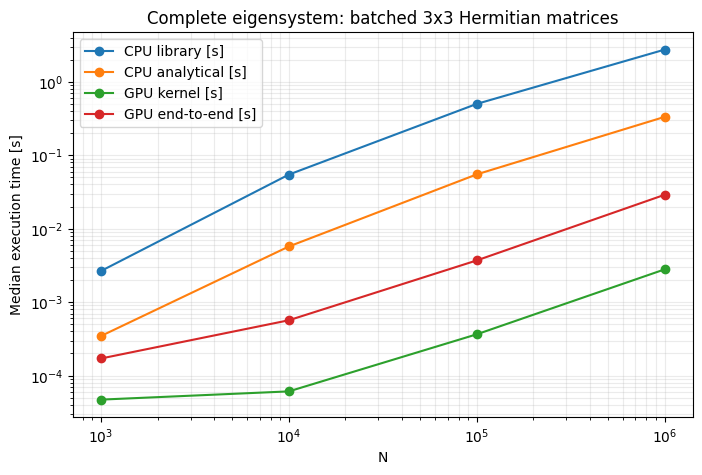

In [11]:

ax = results.plot(
    x='N',
    y=['CPU library [s]', 'CPU analytical [s]', 'GPU kernel [s]', 'GPU end-to-end [s]'],
    marker='o',
    logx=True,
    logy=True,
    figsize=(8, 5),
)
ax.set_ylabel('Median execution time [s]')
ax.set_title('Complete eigensystem: batched 3x3 Hermitian matrices')
ax.grid(True, which='both', alpha=0.25)
plt.show()



## Notes on interpretation

The analytical method is designed for speed on fixed-size $3\times3$ problems. Its main numerical limitation is the same one emphasized by Kopp: Cardano's reconstruction can lose relative accuracy when eigenvalues span many orders of magnitude, and cross-product eigenvectors can become sensitive when eigenvalues are nearly degenerate. The safeguards in this notebook improve behavior near degeneracy, but they do not turn the analytical method into a fully general replacement for a robust iterative Hermitian eigensolver.

For performance studies, the **GPU kernel** time is the relevant quantity when the batch is already resident on the device as part of a larger GPU pipeline. The **GPU end-to-end** time is the relevant quantity when matrices originate on the host and the eigensystems must immediately be copied back.
